# House Prices - Advanced Regression Techniques

## Setup

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import dagshub

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

dagshub.init(repo_owner='mkakh22', repo_name='house-prices-mlflow', mlflow=True)
mlflow.set_experiment("house-prices-experiments")

print("Setup complete!")

Initialized MLflow to track repo "mkakh22/house-prices-mlflow"

Repository mkakh22/house-prices-mlflow initialized!

Setup complete!


## Data Loading and Exploration

In [54]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Cleaning and Feature Engineering

In [55]:
def preprocess_data(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    target = train_df['SalePrice']
    train_df = train_df.drop(columns=['SalePrice'])
    
    combined = pd.concat([train_df, test_df], axis=0)
    combined = combined.drop(columns=['Id'])
    
    numeric_cols = combined.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        combined[col] = combined[col].fillna(combined[col].median())
    
    cat_cols = combined.select_dtypes(include=['object']).columns
    for col in cat_cols:
        combined[col] = combined[col].fillna('None')
    
    combined['TotalSF'] = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']
    combined['TotalBath'] = combined['FullBath'] + 0.5 * combined['HalfBath']
    combined['HouseAge'] = combined['YrSold'] - combined['YearBuilt']
    combined['RemodAge'] = combined['YrSold'] - combined['YearRemodAdd']
    
    for col in cat_cols:
        le = LabelEncoder()
        combined[col] = le.fit_transform(combined[col].astype(str))
    
    n_train = len(train_df)
    train_clean = combined.iloc[:n_train].copy()
    test_clean = combined.iloc[n_train:].copy()
    
    train_clean['SalePrice'] = target.values
    
    return train_clean, test_clean

train_clean, test_clean = preprocess_data(train, test)

X_all = train_clean.drop(columns=['SalePrice'])
y_all = np.log(train_clean['SalePrice'])

print(f"Before feature selection: {X_all.shape[1]} features")
print("Data cleaned!")

Before feature selection: 83 features
Data cleaned!


## Feature Selection

SelectKBest features: 25
RF Importance features: 25
Correlation features: 25


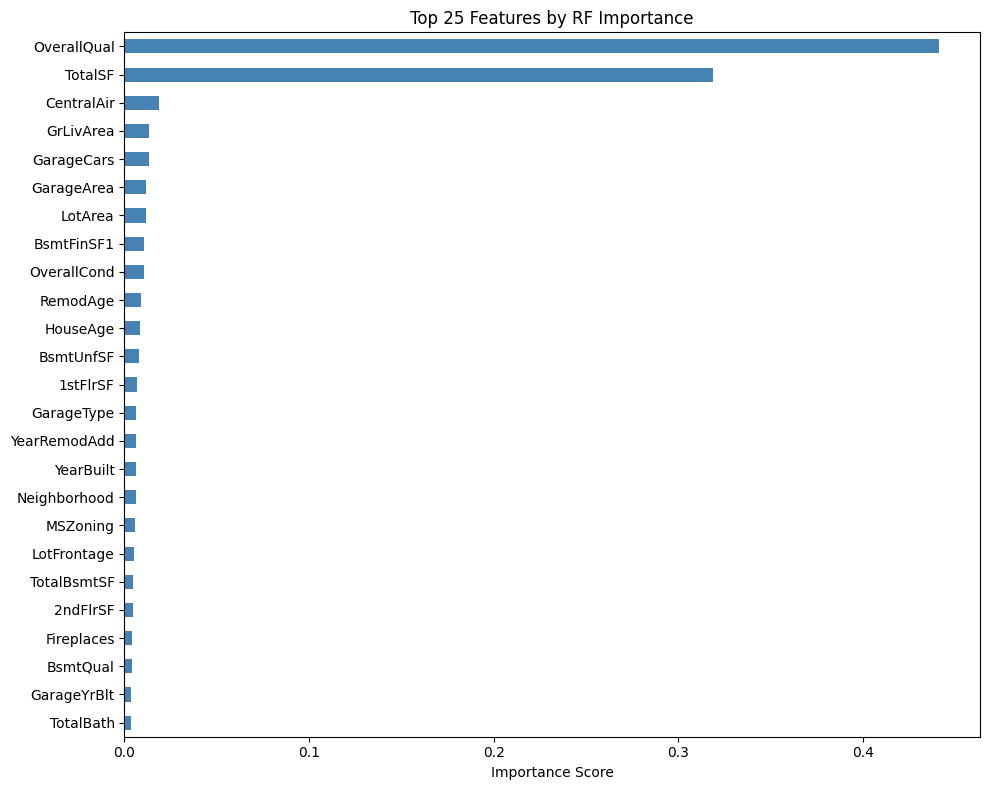


Using RF Importance features: 25 features
Selected features:
['OverallQual', 'TotalSF', 'CentralAir', 'GrLivArea', 'GarageCars', 'GarageArea', 'LotArea', 'BsmtFinSF1', 'OverallCond', 'RemodAge', 'HouseAge', 'BsmtUnfSF', '1stFlrSF', 'GarageType', 'YearRemodAdd', 'YearBuilt', 'Neighborhood', 'MSZoning', 'LotFrontage', 'TotalBsmtSF', '2ndFlrSF', 'Fireplaces', 'BsmtQual', 'GarageYrBlt', 'TotalBath']


In [56]:
from sklearn.feature_selection import SelectKBest, f_regression

# Method 1: SelectKBest (F-score)
selector = SelectKBest(f_regression, k=25)
selector.fit(X_all, y_all)
selected_mask = selector.get_support()
features_kbest = X_all.columns[selected_mask].tolist()

# Method 2: RandomForest Feature Importance
from sklearn.ensemble import RandomForestRegressor
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_all, y_all)
importances = pd.Series(rf_selector.feature_importances_, index=X_all.columns)
features_rf = importances.nlargest(25).index.tolist()

# Method 3: Correlation
correlations = X_all.corrwith(y_all).abs()
features_corr = correlations.nlargest(25).index.tolist()

print(f"SelectKBest features: {len(features_kbest)}")
print(f"RF Importance features: {len(features_rf)}")
print(f"Correlation features: {len(features_corr)}")

# Plot RF Importance scores (best method)
importances.nlargest(25).sort_values().plot(
    kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Top 25 Features by RF Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

X = X_all[features_rf]
print(f"\nUsing RF Importance features: {len(features_rf)} features")
print(f"Selected features:\n{features_rf}")

## Training

In [57]:
from sklearn.tree import DecisionTreeRegressor

#split: 70% - train, 15% - val, 15% - test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_all, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train size:      {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test size:       {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Features used:   {X_train.shape[1]}")

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

Train size:      1022 (70%)
Validation size: 219 (15%)
Test size:       219 (15%)
Features used:   25


In [58]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "DecisionTree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
}

results = {}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        
        model.fit(X_train, y_train)
        
        y_pred_train = model.predict(X_train)
        y_pred_val   = model.predict(X_val)
        y_pred_test  = model.predict(X_test)
        
        train_rmse = rmse(y_train, y_pred_train)
        val_rmse   = rmse(y_val,   y_pred_val)
        test_rmse  = rmse(y_test,  y_pred_test)
        
        mlflow.log_param("model_name", name)
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse",   val_rmse)
        mlflow.log_metric("test_rmse",  test_rmse)
        
        results[name] = {
            "train_rmse": train_rmse,
            "val_rmse":   val_rmse,
            "test_rmse":  test_rmse
        }
        
        print(f"{name:20s} | Train: {train_rmse:.4f} | Val: {val_rmse:.4f} | Test: {test_rmse:.4f}")

print("\nAll models logged to MLflow/DagsHub!")

LinearRegression     | Train: 0.1525 | Val: 0.1514 | Test: 0.1511
🏃 View run LinearRegression at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/135c9709ebb849d29f58b958aa8d9575
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
Ridge                | Train: 0.1526 | Val: 0.1513 | Test: 0.1500
🏃 View run Ridge at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/dd866e984a8d43aba5e60b476c1befbb
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
Lasso                | Train: 0.1527 | Val: 0.1513 | Test: 0.1497
🏃 View run Lasso at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/c980db67113c4ffeaf22f2b4d57ca674
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
ElasticNet           | Train: 0.1526 | Val: 0.1513 | Test: 0.1503
🏃 View run ElasticNet at: https://dagshub.com/mkakh22/ho

                  train_rmse  val_rmse  test_rmse
RandomForest          0.0548    0.1421     0.1217
XGBoost               0.0192    0.1439     0.1233
LightGBM              0.0371    0.1445     0.1246
Lasso                 0.1527    0.1513     0.1497
Ridge                 0.1526    0.1513     0.1500
ElasticNet            0.1526    0.1513     0.1503
LinearRegression      0.1525    0.1514     0.1511
DecisionTree          0.1505    0.1899     0.1635


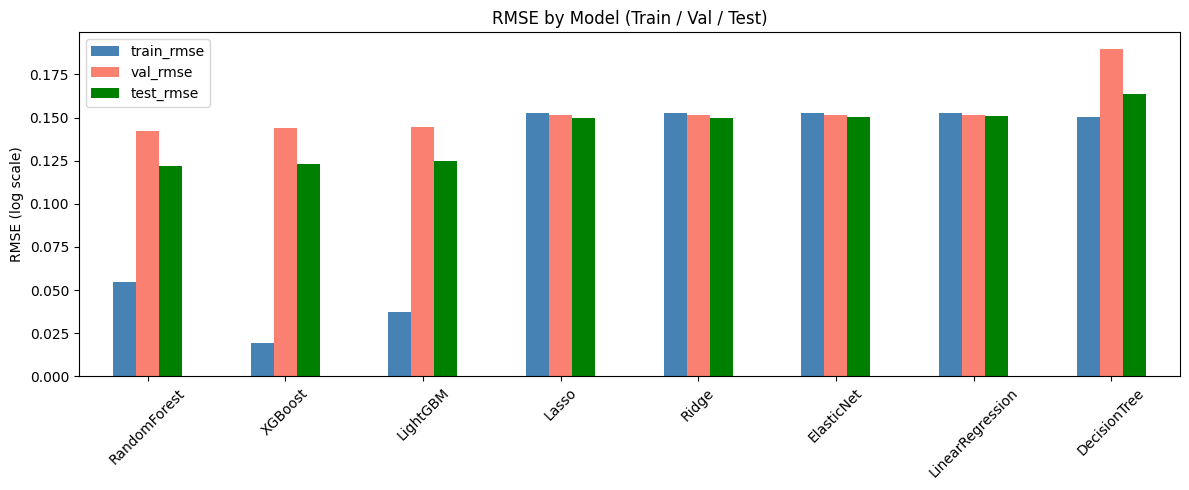


 Best model: RandomForest
   Val RMSE:  0.1421
   Test RMSE: 0.1217


In [59]:
results_df = pd.DataFrame(results).T.sort_values('val_rmse')
print(results_df.round(4))

results_df[['train_rmse', 'val_rmse', 'test_rmse']].plot(
    kind='bar', figsize=(12, 5),
    color=['steelblue', 'salmon', 'green'],
    title='RMSE by Model (Train / Val / Test)'
)
plt.ylabel('RMSE (log scale)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_model = results_df.index[0]
print(f"\n Best model: {best_model}")
print(f"   Val RMSE:  {results_df.loc[best_model, 'val_rmse']:.4f}")
print(f"   Test RMSE: {results_df.loc[best_model, 'test_rmse']:.4f}")

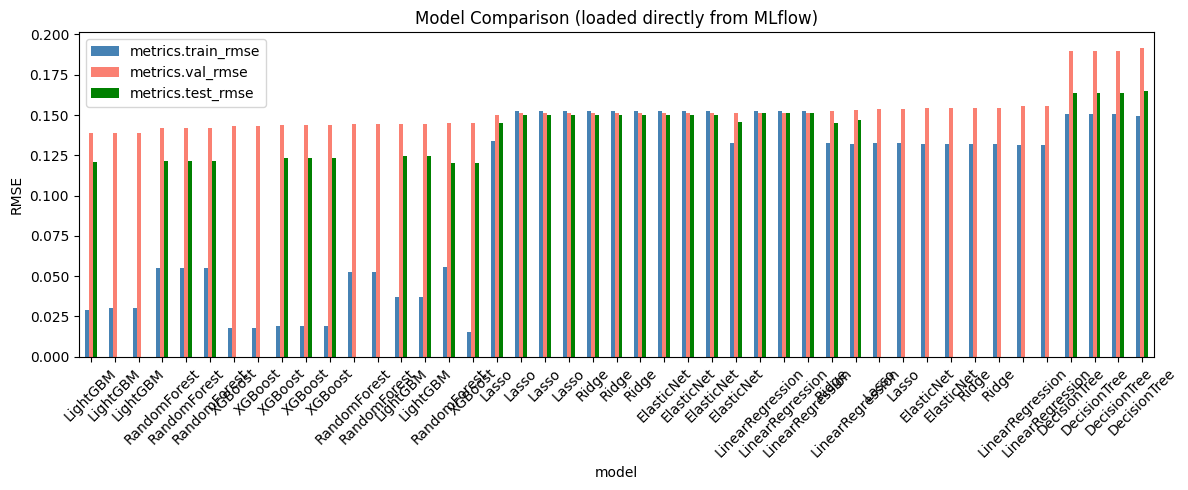

                  metrics.train_rmse  metrics.val_rmse  metrics.test_rmse
model                                                                    
LightGBM                      0.0289            0.1387             0.1208
LightGBM                      0.0300            0.1387                NaN
LightGBM                      0.0300            0.1387                NaN
RandomForest                  0.0548            0.1421             0.1217
RandomForest                  0.0548            0.1421             0.1217
RandomForest                  0.0548            0.1421             0.1217
XGBoost                       0.0179            0.1434                NaN
XGBoost                       0.0179            0.1434                NaN
XGBoost                       0.0192            0.1439             0.1233
XGBoost                       0.0192            0.1439             0.1233
XGBoost                       0.0192            0.1439             0.1233
RandomForest                  0.0523  

In [60]:
runs = mlflow.search_runs(experiment_names=["house-prices-experiments"])

main_runs = runs[runs['tags.mlflow.runName'].isin([
    'LinearRegression', 'Ridge', 'Lasso', 'ElasticNet',
    'DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM'
])]

plot_data = main_runs[['tags.mlflow.runName', 'metrics.train_rmse', 
                        'metrics.val_rmse', 'metrics.test_rmse']].copy()
plot_data = plot_data.rename(columns={'tags.mlflow.runName': 'model'})
plot_data = plot_data.set_index('model').sort_values('metrics.val_rmse')

plot_data[['metrics.train_rmse', 'metrics.val_rmse', 'metrics.test_rmse']].plot(
    kind='bar', figsize=(12, 5),
    color=['steelblue', 'salmon', 'green'],
    title='Model Comparison (loaded directly from MLflow)'
)
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(plot_data.round(4))

## Overfitting and Underfitting Analysis

In [61]:

overfit_underfit_models = {
    # Underfitting
    "DT_depth1_underfit": DecisionTreeRegressor(max_depth=1, random_state=42),
    "DT_depth2_underfit": DecisionTreeRegressor(max_depth=2, random_state=42),
    # Good balance
    "DT_depth5_balanced": DecisionTreeRegressor(max_depth=5, random_state=42),
    # Overfitting
    "DT_depth15_overfit": DecisionTreeRegressor(max_depth=15, random_state=42),
    "DT_depthNone_overfit": DecisionTreeRegressor(max_depth=None, random_state=42),
    # XGBoost overfitting 
    
    "XGB_overfit": XGBRegressor(n_estimators=1000, learning_rate=0.5, max_depth=10, random_state=42),
    # XGBoost underfitting  
    "XGB_underfit": XGBRegressor(n_estimators=10, learning_rate=0.01, max_depth=2, random_state=42),
}

overfit_results = {}

for name, model in overfit_underfit_models.items():
    with mlflow.start_run(run_name=f"analysis_{name}"):
        model.fit(X_train, y_train)
        
        y_pred_train = model.predict(X_train)
        y_pred_val   = model.predict(X_val)
        y_pred_test  = model.predict(X_test)
        
        train_rmse = rmse(y_train, y_pred_train)
        val_rmse   = rmse(y_val,   y_pred_val)
        test_rmse  = rmse(y_test,  y_pred_test)
        
        gap = val_rmse - train_rmse
        if train_rmse > 0.15:
            fit_status = "underfit"
        elif gap > 0.08:
            fit_status = "overfit"
        else:
            fit_status = "good_fit"
        
        mlflow.log_param("model_name", name)
        mlflow.log_param("fit_status", fit_status)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse",   val_rmse)
        mlflow.log_metric("test_rmse",  test_rmse)
        mlflow.log_metric("overfit_gap", gap)
        
        overfit_results[name] = {
            "train_rmse": train_rmse,
            "val_rmse": val_rmse,
            "test_rmse": test_rmse,
            "gap": gap,
            "status": fit_status
        }
        
        print(f"{name:30s} | Train: {train_rmse:.4f} | Val: {val_rmse:.4f} | Gap: {gap:.4f} | {fit_status}")

DT_depth1_underfit             | Train: 0.2918 | Val: 0.3002 | Gap: 0.0084 | underfit
🏃 View run analysis_DT_depth1_underfit at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/606f1c7e08c54627840bb15940f4c726
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
DT_depth2_underfit             | Train: 0.2295 | Val: 0.2289 | Gap: -0.0007 | underfit
🏃 View run analysis_DT_depth2_underfit at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/b484696d4f684df0bb2e91585415a977
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
DT_depth5_balanced             | Train: 0.1505 | Val: 0.1899 | Gap: 0.0395 | underfit
🏃 View run analysis_DT_depth5_balanced at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/aea30aa8d44247fba4f8234d7792f36b
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
DT_dep

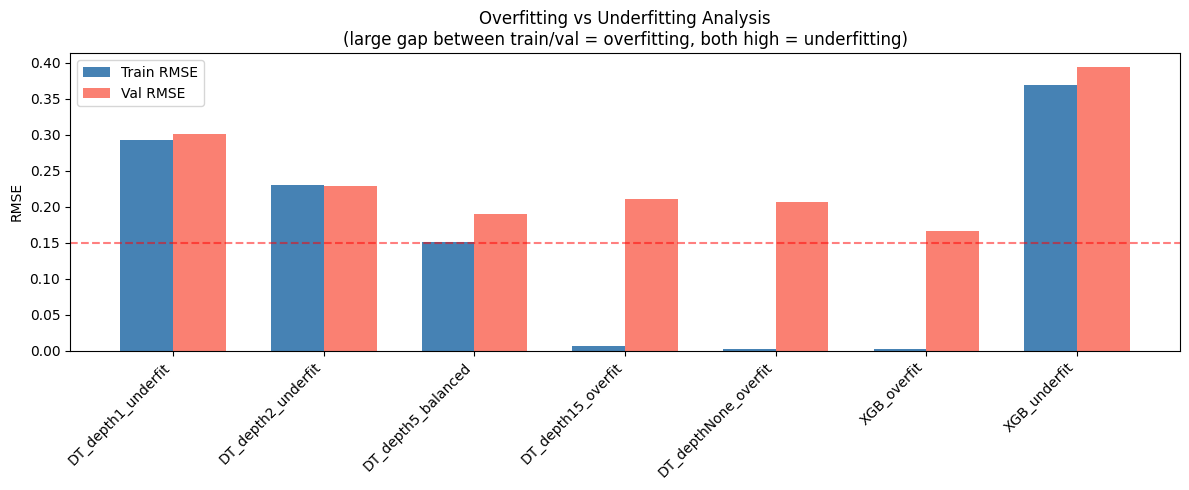


Fit Status Summary:
                     train_rmse  val_rmse       gap    status
DT_depth1_underfit     0.291787  0.300203  0.008416  underfit
DT_depth2_underfit     0.229547  0.228895 -0.000652  underfit
DT_depth5_balanced     0.150463  0.189939  0.039476  underfit
DT_depth15_overfit     0.006733  0.209991  0.203258   overfit
DT_depthNone_overfit   0.001629  0.206784  0.205155   overfit
XGB_overfit            0.001778  0.166332  0.164554   overfit
XGB_underfit           0.369402  0.393473  0.024071  underfit


In [62]:
overfit_df = pd.DataFrame(overfit_results).T

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(overfit_df))
width = 0.35

ax.bar([i - width/2 for i in x], overfit_df['train_rmse'], width, label='Train RMSE', color='steelblue')
ax.bar([i + width/2 for i in x], overfit_df['val_rmse'],   width, label='Val RMSE',   color='salmon')

ax.set_xticks(list(x))
ax.set_xticklabels(overfit_df.index, rotation=45, ha='right')
ax.set_ylabel('RMSE')
ax.set_title('Overfitting vs Underfitting Analysis\n(large gap between train/val = overfitting, both high = underfitting)')
ax.legend()
ax.axhline(y=0.15, color='red', linestyle='--', alpha=0.5, label='Underfit threshold')
plt.tight_layout()
plt.show()

print("\nFit Status Summary:")
print(overfit_df[['train_rmse', 'val_rmse', 'gap', 'status']].round(4))

## Cleaning Approaches Comparison

In [63]:
def preprocess_approach_A(train_df, test_df):
    """Approach A: median fill + label encode"""
    train_df = train_df.copy()
    test_df = test_df.copy()
    target = train_df['SalePrice']
    train_df = train_df.drop(columns=['SalePrice'])
    combined = pd.concat([train_df, test_df], axis=0)
    combined = combined.drop(columns=['Id'])
    
    for col in combined.select_dtypes(include=[np.number]).columns:
        combined[col] = combined[col].fillna(combined[col].median())
    for col in combined.select_dtypes(include=['object']).columns:
        combined[col] = combined[col].fillna('None')
    
    combined['TotalSF']   = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']
    combined['TotalBath'] = combined['FullBath'] + 0.5 * combined['HalfBath']
    combined['HouseAge']  = combined['YrSold'] - combined['YearBuilt']
    combined['RemodAge']  = combined['YrSold'] - combined['YearRemodAdd']
    
    for col in combined.select_dtypes(include=['object']).columns:
        combined[col] = LabelEncoder().fit_transform(combined[col].astype(str))
    
    n = len(train_df)
    train_clean = combined.iloc[:n].copy()
    test_clean  = combined.iloc[n:].copy()
    train_clean['SalePrice'] = target.values
    return train_clean, test_clean


def preprocess_approach_B(train_df, test_df):
    """Approach B: mean fill + drop high-missing columns (>50% missing)"""
    train_df = train_df.copy()
    test_df = test_df.copy()
    target = train_df['SalePrice']
    train_df = train_df.drop(columns=['SalePrice'])
    combined = pd.concat([train_df, test_df], axis=0)
    combined = combined.drop(columns=['Id'])
    
    missing_pct = combined.isnull().mean()
    high_missing = missing_pct[missing_pct > 0.5].index.tolist()
    combined = combined.drop(columns=high_missing)
    print(f"  Approach B: dropped {len(high_missing)} high-missing columns: {high_missing}")
    
    for col in combined.select_dtypes(include=[np.number]).columns:
        combined[col] = combined[col].fillna(combined[col].mean())
    for col in combined.select_dtypes(include=['object']).columns:
        combined[col] = combined[col].fillna('Unknown')
    
    combined['TotalSF']   = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']
    combined['TotalBath'] = combined['FullBath'] + 0.5 * combined['HalfBath']
    combined['HouseAge']  = combined['YrSold'] - combined['YearBuilt']
    combined['RemodAge']  = combined['YrSold'] - combined['YearRemodAdd']
    
    for col in combined.select_dtypes(include=['object']).columns:
        combined[col] = LabelEncoder().fit_transform(combined[col].astype(str))
    
    n = len(train_df)
    train_clean = combined.iloc[:n].copy()
    test_clean  = combined.iloc[n:].copy()
    train_clean['SalePrice'] = target.values
    return train_clean, test_clean


def preprocess_approach_C(train_df, test_df):
    """Approach C: median fill + missing indicator columns"""
    train_df = train_df.copy()
    test_df = test_df.copy()
    target = train_df['SalePrice']
    train_df = train_df.drop(columns=['SalePrice'])
    combined = pd.concat([train_df, test_df], axis=0)
    combined = combined.drop(columns=['Id'])
    
    # Add missing indicator columns for numeric cols with nulls
    numeric_cols = combined.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if combined[col].isnull().sum() > 0:
            combined[f'{col}_was_missing'] = combined[col].isnull().astype(int)
    
    for col in numeric_cols:
        combined[col] = combined[col].fillna(combined[col].median())
    for col in combined.select_dtypes(include=['object']).columns:
        combined[col] = combined[col].fillna('None')
    
    combined['TotalSF']   = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']
    combined['TotalBath'] = combined['FullBath'] + 0.5 * combined['HalfBath']
    combined['HouseAge']  = combined['YrSold'] - combined['YearBuilt']
    combined['RemodAge']  = combined['YrSold'] - combined['YearRemodAdd']
    
    for col in combined.select_dtypes(include=['object']).columns:
        combined[col] = LabelEncoder().fit_transform(combined[col].astype(str))
    
    n = len(train_df)
    train_clean = combined.iloc[:n].copy()
    test_clean  = combined.iloc[n:].copy()
    train_clean['SalePrice'] = target.values
    return train_clean, test_clean


🔄 Testing Approach_A_median_fill...
  Train: 0.1604 | Val: 0.1624 | Test: 0.1540 | Features: 25
🏃 View run Approach_A_median_fill at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/4a2678d62861494383bb2697636d3219
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0

🔄 Testing Approach_B_mean_drop_high_missing...
  Approach B: dropped 5 high-missing columns: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
  Train: 0.1620 | Val: 0.1668 | Test: 0.1541 | Features: 25
🏃 View run Approach_B_mean_drop_high_missing at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/77f6ac935a49415dafcbfed7ac1a383d
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0

🔄 Testing Approach_C_missing_indicators...
  Train: 0.1604 | Val: 0.1624 | Test: 0.1540 | Features: 25
🏃 View run Approach_C_missing_indicators at: https://dagshub.com/mkakh22/house-prices-mlflow.mlf

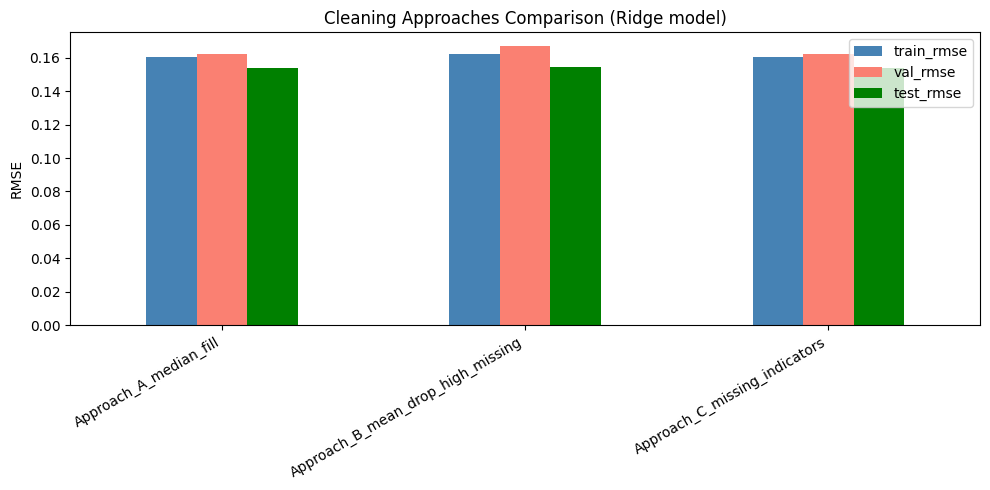

In [64]:
from sklearn.feature_selection import SelectKBest, f_regression

cleaning_approaches = {
    "Approach_A_median_fill": preprocess_approach_A,
    "Approach_B_mean_drop_high_missing": preprocess_approach_B,
    "Approach_C_missing_indicators": preprocess_approach_C,
}

cleaning_results = {}

for approach_name, preprocess_fn in cleaning_approaches.items():
    print(f"\n Testing {approach_name}...")
    
    tc, _ = preprocess_fn(train, test)
    X_a = tc.drop(columns=['SalePrice'])
    y_a = np.log(tc['SalePrice'])
    
    k = min(25, X_a.shape[1])
    sel = SelectKBest(f_regression, k=k)
    sel.fit(X_a, y_a)
    mask = sel.get_support()
    feats = X_a.columns[mask].tolist()
    X_a = X_a[feats]
    
    Xtr, Xtemp, ytr, ytemp = train_test_split(X_a, y_a, test_size=0.3, random_state=42)
    Xv, Xt, yv, yt = train_test_split(Xtemp, ytemp, test_size=0.5, random_state=42)
    
    model = Ridge(alpha=10)
    
    with mlflow.start_run(run_name=approach_name):
        model.fit(Xtr, ytr)
        
        tr_rmse  = rmse(ytr,  model.predict(Xtr))
        val_rmse = rmse(yv,   model.predict(Xv))
        tst_rmse = rmse(yt,   model.predict(Xt))
        
        mlflow.log_param("cleaning_approach", approach_name)
        mlflow.log_param("n_features", len(feats))
        mlflow.log_metric("train_rmse", tr_rmse)
        mlflow.log_metric("val_rmse",   val_rmse)
        mlflow.log_metric("test_rmse",  tst_rmse)
        
        cleaning_results[approach_name] = {
            "train_rmse": tr_rmse,
            "val_rmse":   val_rmse,
            "test_rmse":  tst_rmse,
            "n_features": len(feats)
        }
        
        print(f"  Train: {tr_rmse:.4f} | Val: {val_rmse:.4f} | Test: {tst_rmse:.4f} | Features: {len(feats)}")

print("\nCleaning approaches compared and logged!")

# Summary
cleaning_df = pd.DataFrame(cleaning_results).T
print("\nCleaning Approaches Summary:")
print(cleaning_df.round(4))

cleaning_df[['train_rmse', 'val_rmse', 'test_rmse']].plot(
    kind='bar', figsize=(10, 5),
    color=['steelblue', 'salmon', 'green'],
    title='Cleaning Approaches Comparison (Ridge model)'
)
plt.ylabel('RMSE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Feature Selection Approaches Comparison

In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

train_clean_a, _ = preprocess_approach_A(train, test)
X_fs = train_clean_a.drop(columns=['SalePrice'])
y_fs = np.log(train_clean_a['SalePrice'])

# Method 1: SelectKBest(F-score)
selector_kbest = SelectKBest(f_regression, k=25)
selector_kbest.fit(X_fs, y_fs)
features_kbest = X_fs.columns[selector_kbest.get_support()].tolist()

# Method 2: RandomForest Feature Importance
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_fs, y_fs)
importances = pd.Series(rf_selector.feature_importances_, index=X_fs.columns)
features_rf = importances.nlargest(25).index.tolist()

# Method 3: Correlation with target
correlations = X_fs.corrwith(y_fs).abs()
features_corr = correlations.nlargest(25).index.tolist()

print(f"KBest features:       {len(features_kbest)}")
print(f"RF Importance:        {len(features_rf)}")
print(f"Correlation features: {len(features_corr)}")

# overlap
set_kbest = set(features_kbest)
set_rf = set(features_rf)
set_corr = set(features_corr)
print(f"\nOverlap KBest & RF:   {len(set_kbest & set_rf)} features")
print(f"Overlap KBest & Corr: {len(set_kbest & set_corr)} features")
print(f"Overlap RF & Corr:    {len(set_rf & set_corr)} features")

KBest features:       25
RF Importance:        25
Correlation features: 25

Overlap KBest & RF:   17 features
Overlap KBest & Corr: 25 features
Overlap RF & Corr:    17 features


In [66]:
feature_selection_methods = {
    "FS_SelectKBest_25":   features_kbest,
    "FS_RF_Importance_25": features_rf,
    "FS_Correlation_25":   features_corr,
    "FS_All_features":     X_fs.columns.tolist(),
}

test_models = {
    "Ridge":        Ridge(alpha=10),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost":      XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbosity=0),
}

fs_results = {}

for fs_name, features in feature_selection_methods.items():
    X_sel = X_fs[features]
    Xtr, Xtemp, ytr, ytemp = train_test_split(X_sel, y_fs, test_size=0.3, random_state=42)
    Xv, Xt, yv, yt = train_test_split(Xtemp, ytemp, test_size=0.5, random_state=42)
    
    for model_name, model in test_models.items():
        run_name = f"{fs_name}_{model_name}"
        
        with mlflow.start_run(run_name=run_name):
            model.fit(Xtr, ytr)
            
            tr_rmse  = rmse(ytr, model.predict(Xtr))
            val_rmse = rmse(yv,  model.predict(Xv))
            tst_rmse = rmse(yt,  model.predict(Xt))
            
            mlflow.log_param("feature_selection", fs_name)
            mlflow.log_param("model", model_name)
            mlflow.log_param("n_features", len(features))
            mlflow.log_metric("train_rmse", tr_rmse)
            mlflow.log_metric("val_rmse",   val_rmse)
            mlflow.log_metric("test_rmse",  tst_rmse)
            
            fs_results[run_name] = {
                "feature_selection": fs_name,
                "model": model_name,
                "n_features": len(features),
                "train_rmse": tr_rmse,
                "val_rmse":   val_rmse,
                "test_rmse":  tst_rmse
            }
            
            print(f"{fs_name:25s} | {model_name:15s} | Val: {val_rmse:.4f} | Test: {tst_rmse:.4f}")

print("\nFeature selection methods compared and logged!")

FS_SelectKBest_25         | Ridge           | Val: 0.1624 | Test: 0.1540
🏃 View run FS_SelectKBest_25_Ridge at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/7c25e148e01845eda11102fdf6aac4b9
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
FS_SelectKBest_25         | RandomForest    | Val: 0.1553 | Test: 0.1337
🏃 View run FS_SelectKBest_25_RandomForest at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/f3fcf87a6bd743b89305443412d51cc2
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
FS_SelectKBest_25         | XGBoost         | Val: 0.1641 | Test: 0.1428
🏃 View run FS_SelectKBest_25_XGBoost at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/a9cf7687f6834e6a9a904cc0be6c55f9
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
FS_RF_Importance_25       | Ridge           | Val

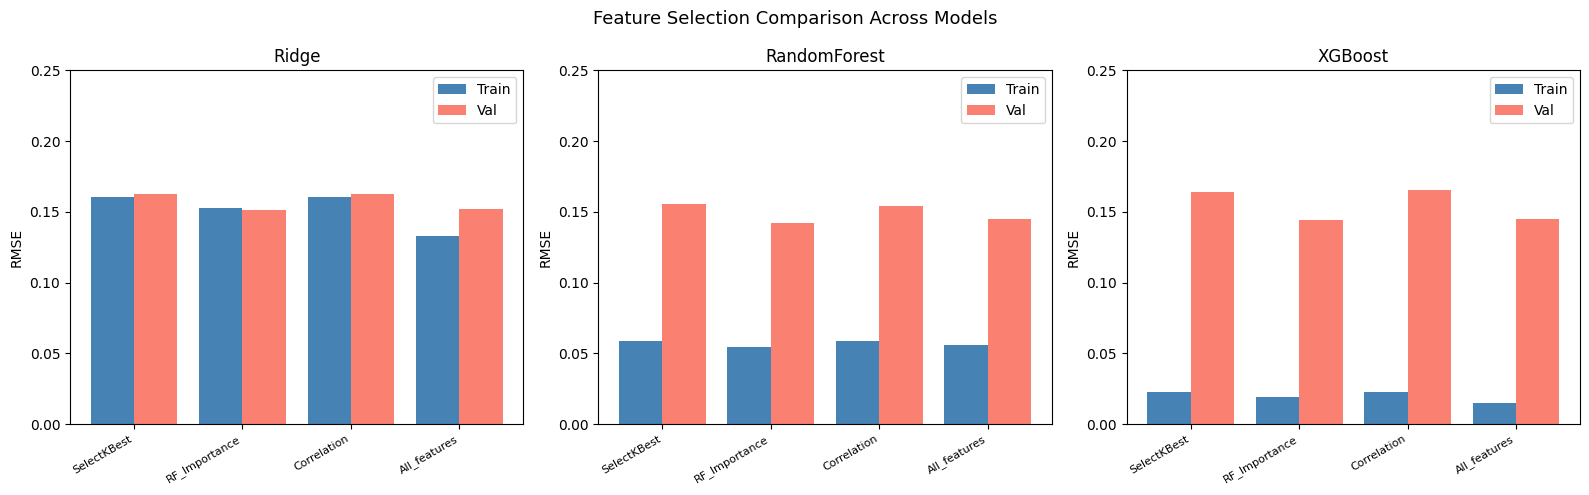


 Best combination: FS_RF_Importance_25 + RandomForest
   Val RMSE: 0.1421
   Test RMSE: 0.1217


In [67]:
fs_df = pd.DataFrame(fs_results).T

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, model_name in enumerate(["Ridge", "RandomForest", "XGBoost"]):
    subset = fs_df[fs_df['model'] == model_name].copy()
    subset['val_rmse'] = subset['val_rmse'].astype(float)
    subset['train_rmse'] = subset['train_rmse'].astype(float)
    
    x = range(len(subset))
    axes[i].bar([j - 0.2 for j in x], subset['train_rmse'].values, 0.4, 
                label='Train', color='steelblue')
    axes[i].bar([j + 0.2 for j in x], subset['val_rmse'].values, 0.4, 
                label='Val', color='salmon')
    axes[i].set_title(f'{model_name}')
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(
        [s.replace('FS_', '').replace('_25', '') for s in subset['feature_selection'].values],
        rotation=30, ha='right', fontsize=8
    )
    axes[i].set_ylabel('RMSE')
    axes[i].legend()
    axes[i].set_ylim(0, 0.25)

plt.suptitle('Feature Selection Comparison Across Models', fontsize=13)
plt.tight_layout()
plt.show()

# Best combination
best = fs_df.loc[fs_df['val_rmse'].astype(float).idxmin()]
print(f"\n Best combination: {best['feature_selection']} + {best['model']}")
print(f"   Val RMSE: {float(best['val_rmse']):.4f}")
print(f"   Test RMSE: {float(best['test_rmse']):.4f}")

## Hyperparameter Optimization with Optuna

In [68]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_lgbm(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    return rmse(y_val, model.predict(X_val))

print("Running Optuna for LightGBM (50 trials)...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

best_params_lgbm = study_lgbm.best_params
print(f"\nBest LightGBM params: {best_params_lgbm}")
print(f"   Best Val RMSE: {study_lgbm.best_value:.4f}")

Running Optuna for LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best LightGBM params: {'n_estimators': 874, 'learning_rate': 0.011875023115441368, 'max_depth': 4, 'num_leaves': 36, 'min_child_samples': 28, 'subsample': 0.90312852829049, 'colsample_bytree': 0.5557391361148841, 'reg_alpha': 0.016060777912609476, 'reg_lambda': 0.03760558175609563}
   Best Val RMSE: 0.1326


In [69]:
def objective_xgb(trial):
    params = {
        'n_estimators':   trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':  trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':      trial.suggest_int('max_depth', 3, 10),
        'subsample':      trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':      trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':     trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbosity': 0
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    return rmse(y_val, model.predict(X_val))

print("🔍 Running Optuna for XGBoost (50 trials)...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

best_params_xgb = study_xgb.best_params
print(f"\nBest XGBoost params: {best_params_xgb}")
print(f"   Best Val RMSE: {study_xgb.best_value:.4f}")

🔍 Running Optuna for XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best XGBoost params: {'n_estimators': 795, 'learning_rate': 0.02218015889164556, 'max_depth': 3, 'subsample': 0.6112872507262676, 'colsample_bytree': 0.6354722041498305, 'reg_alpha': 9.821504670029317e-07, 'reg_lambda': 2.984725998844031e-07}
   Best Val RMSE: 0.1224


In [70]:
with mlflow.start_run(run_name="LightGBM_Optuna_Tuned"):
    model_lgbm_tuned = LGBMRegressor(**best_params_lgbm, random_state=42, verbose=-1)
    model_lgbm_tuned.fit(X_train, y_train)
    
    tr  = rmse(y_train, model_lgbm_tuned.predict(X_train))
    val = rmse(y_val,   model_lgbm_tuned.predict(X_val))
    tst = rmse(y_test,  model_lgbm_tuned.predict(X_test))
    
    mlflow.log_params(best_params_lgbm)
    mlflow.log_param("model_name", "LightGBM_Optuna_Tuned")
    mlflow.log_metric("train_rmse", tr)
    mlflow.log_metric("val_rmse",   val)
    mlflow.log_metric("test_rmse",  tst)
    mlflow.sklearn.log_model(model_lgbm_tuned, "model")
    
    print(f"LightGBM Tuned | Train: {tr:.4f} | Val: {val:.4f} | Test: {tst:.4f}")

with mlflow.start_run(run_name="XGBoost_Optuna_Tuned"):
    model_xgb_tuned = XGBRegressor(**best_params_xgb, random_state=42, verbosity=0)
    model_xgb_tuned.fit(X_train, y_train)
    
    tr  = rmse(y_train, model_xgb_tuned.predict(X_train))
    val = rmse(y_val,   model_xgb_tuned.predict(X_val))
    tst = rmse(y_test,  model_xgb_tuned.predict(X_test))
    
    mlflow.log_params(best_params_xgb)
    mlflow.log_param("model_name", "XGBoost_Optuna_Tuned")
    mlflow.log_metric("train_rmse", tr)
    mlflow.log_metric("val_rmse",   val)
    mlflow.log_metric("test_rmse",  tst)
    mlflow.sklearn.log_model(model_xgb_tuned, "model")
    
    print(f"XGBoost Tuned  | Train: {tr:.4f} | Val: {val:.4f} | Test: {tst:.4f}")

print("\nTuned models logged to MLflow!")

2026/04/13 15:13:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 15:13:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM Tuned | Train: 0.0906 | Val: 0.1326 | Test: 0.1221
🏃 View run LightGBM_Optuna_Tuned at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/c55e735d7c8242008f59fa81add32db2
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0


2026/04/13 15:13:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 15:13:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost Tuned  | Train: 0.0668 | Val: 0.1224 | Test: 0.1130
🏃 View run XGBoost_Optuna_Tuned at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/f160380c1ca24bdf83a45bc2fe63415f
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0

Tuned models logged to MLflow!


## Model Registration

In [71]:
import mlflow.sklearn

best_run_id = "fddc19d9637d4b95a881c52d87bd6512"

with mlflow.start_run(run_id=best_run_id):
    mlflow.sklearn.log_model(
        model_xgb_tuned,
        artifact_path="model",
        registered_model_name="house-prices-best-model"
    )

print("Model registered in MLflow Model Registry!")

2026/04/13 15:13:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 15:13:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'house-prices-best-model' already exists. Creating a new version of this model...
2026/04/13 15:14:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house-prices-best-model, version 2
Created version '2' of model 'house-prices-best-model'.


🏃 View run XGBoost_Optuna_Tuned at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0/runs/fddc19d9637d4b95a881c52d87bd6512
🧪 View experiment at: https://dagshub.com/mkakh22/house-prices-mlflow.mlflow/#/experiments/0
Model registered in MLflow Model Registry!
